<a href="https://colab.research.google.com/github/saraisabella0206-ctrl/INTEGRACION-DE-DATOS-Y-PROSPECTIVA-/blob/main/Reto5_Riesgo_Op_Sara_Isabella_Casta%C3%B1o_Ram%C3%ADrez_(ok).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluación del Riesgo Operacional en Canales Electrónicos**
Por: Sara Isabella Castaño Ramírez

A partir de la base de datos histórica de Eventos de Riesgo Tecnológico ocurridos en los canales electrónicos (App móvil, Sucursal Virtual, Cajeros) de una entidad financiera líder, asumiré el rol de analista de riesgos para transformar estos datos crudos en una herramienta de decisión gerencial que permita cuantificar la exposición económica y la eficacia de los controles actuales. Así, usando la metodología de Riesgo Operacional, desarrollaré y entregaré:

1. **Arquitectura de Matrices:**
   - Frecuencia (Eventos): Conteo de ocurrencias.
   - Severidad: Clasificación por niveles de magnitud del daño.
   - Pérdidas Agregadas: Producto de frecuencia y severidad.
   - Impacto y Gestión: Crear la matriz de impacto y gestión.

2. **Estimación Cuantitativa:**
   - Cálculo de la Pérdida Esperada (PE).
   - Estimación del Operational Value at Risk (OpVaR) a un nivel de confianza del 99,9%.
   - *Nota: se realizará el cálculo comparativo para dos escenarios: Pérdidas No Gestionadas (Riesgo Inherente) vs. Pérdidas Gestionadas (Riesgo Residual).*

3. **Herramienta de Auditoría (Filtro Dinámico):** se creará un tablero o funcionalidad que permita seleccionar cualquier celda de la matriz de pérdidas y despliegue automáticamente el listado detallado y la descripción de los eventos que la componen.

#
**0.Se procede con la carga de las librerías de trabajo**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#
**1. Se crea la función de clusterización para poder utilizarla varias veces**



El método K-Medoidsagrupa los eventos de riesgo en 5 niveles (de menor a mayor) de forma adaptativa: se parte de semillas aleatorias y se actualizan iterativamente hacia la mediana del grupo, lo que lo hace más robusto ante valores extremos que el K-Means clásico.

In [2]:
def clusterizacion(Xi):
  # Se seleccionan 5 semillas aleatorias de los datos de entrada
  XC = np.random.choice(Xi, size=5)
  XC = np.sort(XC)  # Se ordenan para asignar niveles de menor a mayor (Improbable → Frecuente / Leve → Catastrófico)
  nc = np.zeros((len(Xi), 1))  # Se inicializa el vector de pertenencia a cada cluster

  for k in range(len(Xi)):
    d = np.abs(XC - Xi[k])   # Se calcula la distancia de un evento a cada semilla
    nc[k] = np.argmin(d)     # El evento pertenece al cluster más cercano
    nc2 = np.int32(nc[k])    # Se convierte a entero para usarlo como índice
    XC[nc2,] = (XC[nc2,] + Xi[k]) / 2  # Se actualiza la semilla (K-Medoids: promedio acumulado)

  return XC, nc  # Retorna los centroides finales y el cluster al que pertenece cada evento

#
**2. Se cargan los archivos de trabajo y se crean los clusters**

In [3]:
# Se carga la base de datos histórica de fallas tecnológicas en canales electrónicos
nxl = '/content/drive/MyDrive/Colab Notebooks/Excels/5. Riesgo Operacional FallasTecnológicas.xlsx'
XDB = pd.read_excel(nxl, sheet_name=0)
XDB.head()

,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [4]:
# Se fija la semilla para reproducibilidad de los resultados
np.random.seed(42)

# Se extraen las dos variables clave del análisis de riesgo operacional:
# 1. Frecuencia: número de transacciones fallidas por día (col índice 3)
Xf = np.array(XDB.iloc[:, 3])
XCf, ncf = clusterizacion(Xf)  # Se clusteriza en 5 niveles de frecuencia

# 2. Severidad: valor económico promedio generado por las fallas (col índice 4)
Xs = np.array(XDB.iloc[:, 4])
XCs, ncs = clusterizacion(Xs)  # Se clusteriza en 5 niveles de severidad

# Se calcula la distribución de pérdidas agregadas (LDA = Loss Distribution Approach)
# Cada pérdida diaria es el producto de cuántas fallas hubo y cuánto costó cada una
LDA = Xf * Xs
XClda, nclda = clusterizacion(LDA)

# Se construye el DataFrame maestro con frecuencias, severidades y sus niveles de cluster
df = pd.DataFrame(np.column_stack((Xf, ncf, Xs, ncs, LDA, nclda)))
df.columns = ['Freq', 'Nivel_f', 'Sev', 'Nivel_S', 'LDA', 'Nivel_LDA']
df.head()

,Freq,Nivel_f,Sev,Nivel_S,LDA,Nivel_LDA
0,1.0,0.0,0.5374,0.0,0.5374,0.0
1,4.0,0.0,1.1978,2.0,4.7912,2.0
2,5.0,1.0,0.4269,0.0,2.1345,1.0
3,6.0,1.0,1.0814,1.0,6.4884,3.0
4,7.0,2.0,1.2105,2.0,8.4735,4.0


#
**3. Arquitectura de Matrices**



Se procede con la construcción de las matrices de eventos de riesgo operacional.
Cada celda de la matriz cruza un nivel de **frecuencia** (eje Y, filas) con un nivel de **severidad** (eje X, columnas):
- Nivel 0 = más bajo (Improbable / Insignificante)
- Nivel 4 = más alto (Frecuente / Catastrófico)

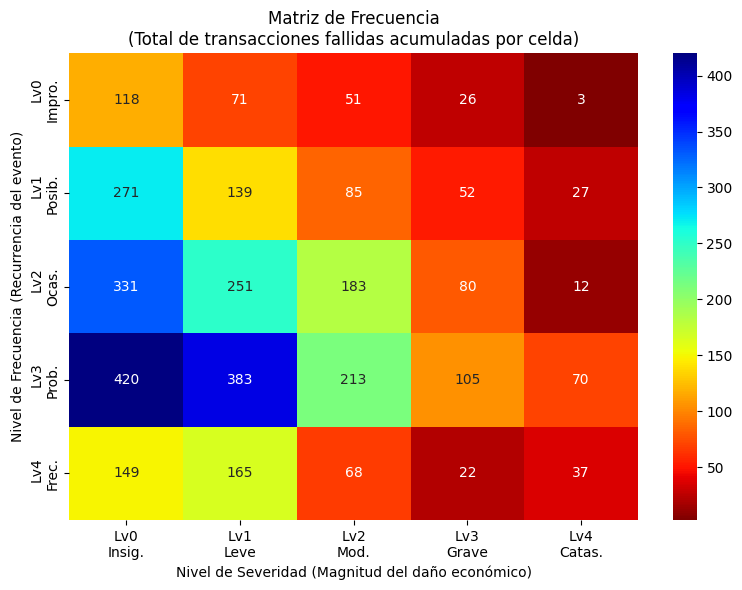

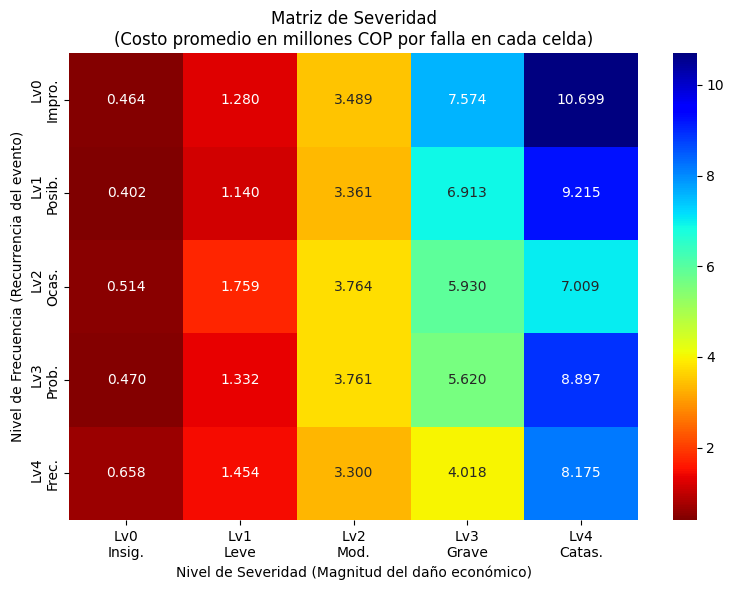

In [5]:
# Se inicializan las dos matrices 5x5 en ceros
MEf = np.zeros((5, 5))  # Matriz de Frecuencia: acumula el conteo de transacciones fallidas por celda
MEs = np.zeros((5, 5))  # Matriz de Severidad: acumula el costo promedio por falla en cada celda

# Se recorre cada evento de la base de datos y se ubica en la celda correspondiente
for k in range(len(Xf)):
  nf = np.int32(df.iloc[k, 1])  # Nivel de frecuencia del evento k (fila de la matriz)
  nc = np.int32(df.iloc[k, 3])  # Nivel de severidad del evento k (columna de la matriz)
  MEf[nf, nc] = MEf[nf, nc] + Xf[k,]          # Se suma el número de fallas al acumulado de esa celda
  MEs[nf, nc] = (MEs[nf, nc] + Xs[k,]) / 2    # Se estima el costo promedio por falla en esa celda

# ── MATRIZ DE FRECUENCIA ────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(MEf, annot=True, fmt='.0f', cmap='jet_r',
            xticklabels=['Lv0\nInsig.', 'Lv1\nLeve', 'Lv2\nMod.', 'Lv3\nGrave', 'Lv4\nCatas.'],
            yticklabels=['Lv0\nImpro.', 'Lv1\nPosib.', 'Lv2\nOcas.', 'Lv3\nProb.', 'Lv4\nFrec.'])
plt.title("Matriz de Frecuencia\n(Total de transacciones fallidas acumuladas por celda)", fontsize=12)
plt.xlabel("Nivel de Severidad (Magnitud del daño económico)")
plt.ylabel("Nivel de Frecuencia (Recurrencia del evento)")
plt.tight_layout()
plt.show()

# ── MATRIZ DE SEVERIDAD ─────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(MEs, annot=True, fmt='.3f', cmap='jet_r',
            xticklabels=['Lv0\nInsig.', 'Lv1\nLeve', 'Lv2\nMod.', 'Lv3\nGrave', 'Lv4\nCatas.'],
            yticklabels=['Lv0\nImpro.', 'Lv1\nPosib.', 'Lv2\nOcas.', 'Lv3\nProb.', 'Lv4\nFrec.'])
plt.title("Matriz de Severidad\n(Costo promedio en millones COP por falla en cada celda)", fontsize=12)
plt.xlabel("Nivel de Severidad (Magnitud del daño económico)")
plt.ylabel("Nivel de Frecuencia (Recurrencia del evento)")
plt.tight_layout()
plt.show()

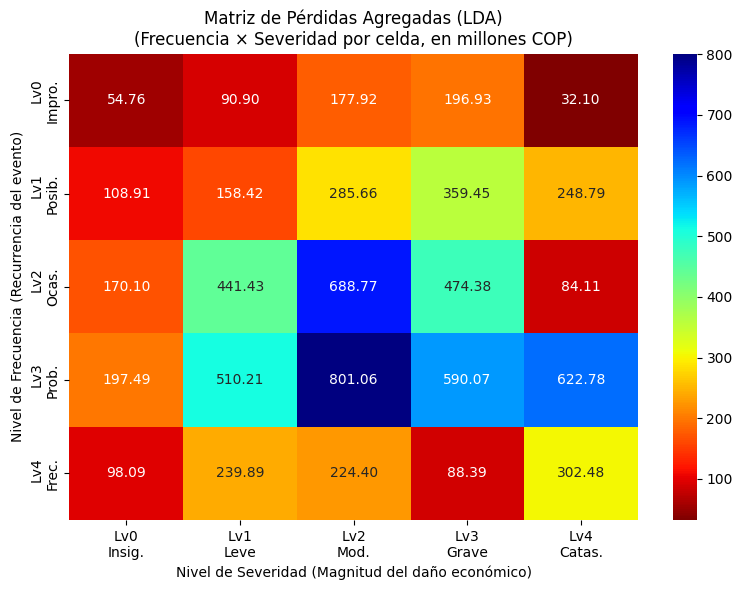

In [6]:
# ── MATRIZ DE PÉRDIDAS AGREGADAS (LDA) ─────────────────────────────────────
# Se calcula la pérdida agregada de cada celda: cuántos eventos hubo × cuánto costó cada uno
MLDA = MEf * MEs  # Pérdida total esperada por celda (en millones de COP)

plt.figure(figsize=(8, 6))
sns.heatmap(MLDA, annot=True, fmt='.2f', cmap='jet_r',
            xticklabels=['Lv0\nInsig.', 'Lv1\nLeve', 'Lv2\nMod.', 'Lv3\nGrave', 'Lv4\nCatas.'],
            yticklabels=['Lv0\nImpro.', 'Lv1\nPosib.', 'Lv2\nOcas.', 'Lv3\nProb.', 'Lv4\nFrec.'])
plt.title("Matriz de Pérdidas Agregadas (LDA)\n(Frecuencia × Severidad por celda, en millones COP)", fontsize=12)
plt.xlabel("Nivel de Severidad (Magnitud del daño económico)")
plt.ylabel("Nivel de Frecuencia (Recurrencia del evento)")
plt.tight_layout()
plt.show()

#
**4. Métricas estadísticas (Pérdida Esperada (PE) y Matriz de Impacto y Gestión)**



Se calculan los indicadores clave para cuantificar la exposición económica del banco ante fallas tecnológicas.

In [7]:
# ── 1. PÉRDIDA ESPERADA POR PROMEDIO SIMPLE ────────────────────────────────
# Trata todas las celdas de la matriz como igualmente probables
ps = np.round(np.mean(MEs), 3)
print(f"Pérdida esperada (promedio simple de severidad por falla): {ps} millones COP")

# ── 2. PÉRDIDA ESPERADA POR PROMEDIO PONDERADO ─────────────────────────────
# Tiene en cuenta que no todas las fallas tienen la misma frecuencia:
# los eventos más comunes pesan más en el cálculo del costo esperado real
pp = np.round(np.sum(MEf * MEs) / np.sum(MEf), 3)
print(f"Pérdida esperada (promedio ponderado por frecuencia):      {pp} millones COP")

Pérdida esperada (promedio simple de severidad por falla): 4.048 millones COP
Pérdida esperada (promedio ponderado por frecuencia):      2.175 millones COP


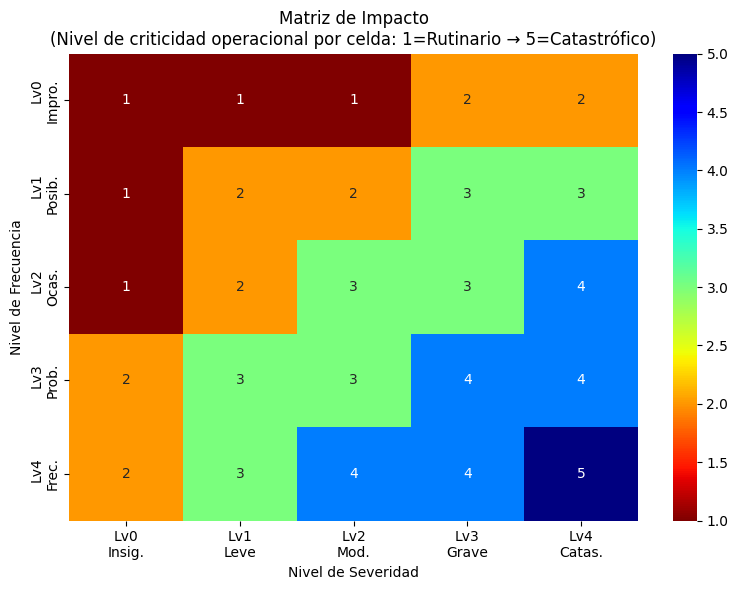

Pérdida esperada ponderada con impacto: 2.812 millones COP


In [8]:
# ── MATRIZ DE IMPACTO ──────────────────────────────────────────────────────
# La matriz de impacto le asigna un nivel de criticidad a cada celda según su
# posición en el cruce frecuencia × severidad. Va de 1 (rutinario) a 5 (catastrófico).
# Esta matriz es el puente entre la medición y la toma de decisiones gerenciales.
MI = np.array([[1, 1, 1, 2, 2],
               [1, 2, 2, 3, 3],
               [1, 2, 3, 3, 4],
               [2, 3, 3, 4, 4],
               [2, 3, 4, 4, 5]])

plt.figure(figsize=(8, 6))
sns.heatmap(MI, annot=True, fmt='.0f', cmap='jet_r',
            xticklabels=['Lv0\nInsig.', 'Lv1\nLeve', 'Lv2\nMod.', 'Lv3\nGrave', 'Lv4\nCatas.'],
            yticklabels=['Lv0\nImpro.', 'Lv1\nPosib.', 'Lv2\nOcas.', 'Lv3\nProb.', 'Lv4\nFrec.'])
plt.title("Matriz de Impacto\n(Nivel de criticidad operacional por celda: 1=Rutinario → 5=Catastrófico)", fontsize=12)
plt.xlabel("Nivel de Severidad")
plt.ylabel("Nivel de Frecuencia")
plt.tight_layout()
plt.show()

# Se recalcula la pérdida esperada ponderando también por el nivel de impacto de cada celda
pp_mi = np.round(np.sum(MEf * MEs * MI) / np.sum(MEf * MI), 3)
print(f"Pérdida esperada ponderada con impacto: {pp_mi} millones COP")

Ingresar el nivel de gestión a aplicar (1, 2, 3 ó 4): 2


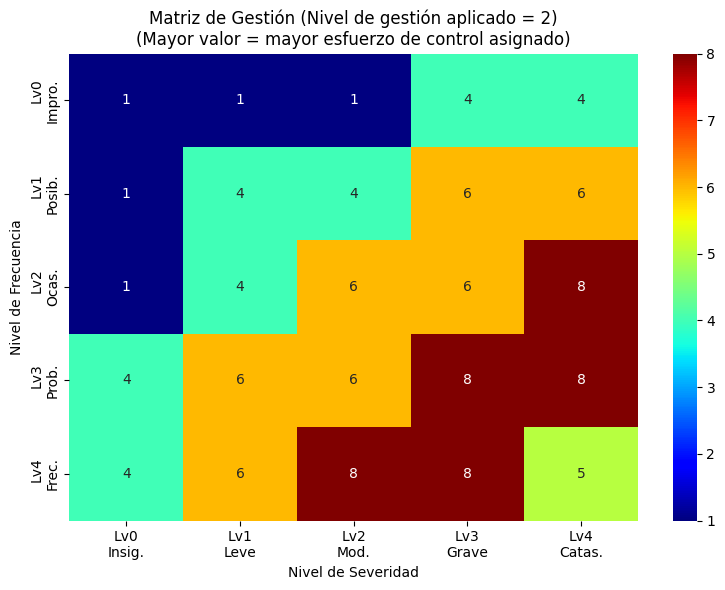

Pérdida esperada con gestión nivel 2: 1.508 millones COP


In [9]:
# ── MATRIZ DE GESTIÓN ──────────────────────────────────────────────────────
# La matriz de gestión escala la atención (recursos, controles) dedicada a cada celda.
# Solo se intensifica la gestión en celdas de nivel 2, 3 y 4 (ni los muy triviales ni los catastróficos).
# El nivel de gestión lo define la organización: a mayor nivel, mayor reducción de pérdidas residuales.
# Ejemplos de acciones por nivel:
#   1 → Monitoreo rutinario del sistema (dashboards de uptime)
#   2 → Revisión de logs y alertas automáticas
#   3 → Activación de protocolos de contingencia y failover
#   4 → Intervención del equipo de ciberseguridad y comunicación a entes reguladores
#   5 → Declaración de incidente crítico, crisis total (nunca se gestiona proactivamente)

NG = np.int32(input("Ingresar el nivel de gestión a aplicar (1, 2, 3 ó 4): "))
MG = np.copy(MI)

# Se multiplica el nivel de impacto por el nivel de gestión para las celdas intermedias
for i in range(5):
  for j in range(5):
    if MG[i, j] > 1 and MG[i, j] < 5:
      MG[i, j] = MG[i, j] * NG  # Se intensifica la gestión en celdas de riesgo medio y alto

plt.figure(figsize=(8, 6))
sns.heatmap(MG, annot=True, fmt='.0f', cmap='jet',
            xticklabels=['Lv0\nInsig.', 'Lv1\nLeve', 'Lv2\nMod.', 'Lv3\nGrave', 'Lv4\nCatas.'],
            yticklabels=['Lv0\nImpro.', 'Lv1\nPosib.', 'Lv2\nOcas.', 'Lv3\nProb.', 'Lv4\nFrec.'])
plt.title(f"Matriz de Gestión (Nivel de gestión aplicado = {NG})\n(Mayor valor = mayor esfuerzo de control asignado)", fontsize=12)
plt.xlabel("Nivel de Severidad")
plt.ylabel("Nivel de Frecuencia")
plt.tight_layout()
plt.show()

# Se estima la pérdida residual: qué tanto se reduce el costo esperado al activar la gestión
png = np.round(np.sum(MEf * MEs * MI) / np.sum(MEf * MG), 3)
print(f"Pérdida esperada con gestión nivel {NG}: {png} millones COP")

#
**5. Estimación Cuantitativa (Pérdida Esperada y OpVaR (99,9%))**



Se estima el capital económico que el banco debería reservar para cubrir pérdidas operacionales extremas. Se comparan dos escenarios:
- **Riesgo Inherente:** sin controles activos (pérdidas no gestionadas)
- **Riesgo Residual:** con controles activados en nivel de gestión 2

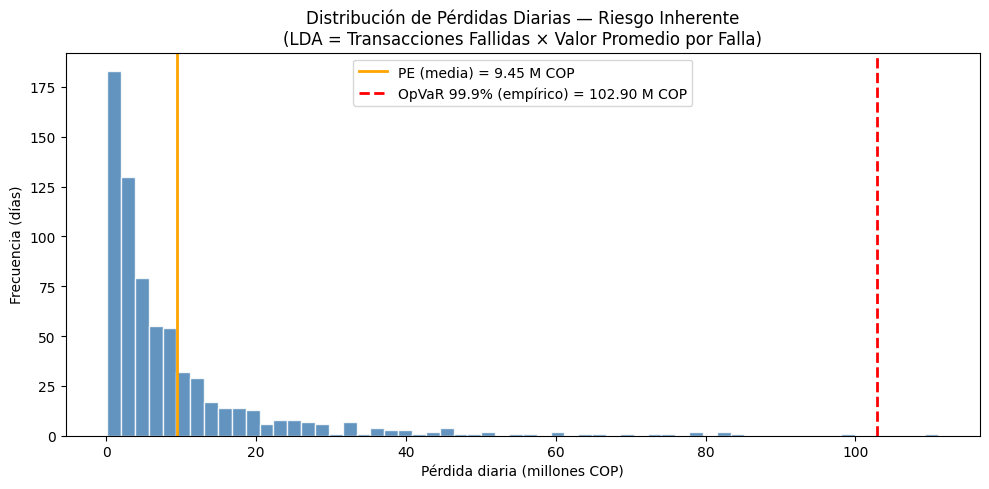

In [10]:
# ── DISTRIBUCIÓN DE PÉRDIDAS (LDA) ────────────────────────────────────────
# Se grafica la distribución histórica de pérdidas diarias para visualizar su forma
plt.figure(figsize=(10, 5))
plt.hist(LDA, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(LDA), color='orange', linewidth=2, label=f'PE (media) = {np.mean(LDA):.2f} M COP')
plt.axvline(np.percentile(LDA, 99.9), color='red', linewidth=2, linestyle='--',
            label=f'OpVaR 99.9% (empírico) = {np.percentile(LDA, 99.9):.2f} M COP')
plt.title("Distribución de Pérdidas Diarias — Riesgo Inherente\n(LDA = Transacciones Fallidas × Valor Promedio por Falla)", fontsize=12)
plt.xlabel("Pérdida diaria (millones COP)")
plt.ylabel("Frecuencia (días)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# ── AJUSTE LOGNORMAL PARA EL OPVAR ─────────────────────────────────────────
# Las pérdidas operacionales suelen seguir una distribución lognormal:
# la mayoría de los días hay pérdidas pequeñas, pero ocasionalmente aparecen pérdidas enormes.
# Se ajusta una lognormal a los datos para estimar el OpVaR de forma paramétrica.

log_LDA = np.log(LDA[LDA > 0])             # Se trabaja en escala logarítmica
mu_log   = np.mean(log_LDA)                 # Parámetro de localización (media del log)
sigma_log = np.std(log_LDA)                 # Parámetro de escala (desv. estándar del log)

# ── ESCENARIO 1: RIESGO INHERENTE (Sin gestión) ─────────────────────────────
PE_inherente    = np.round(np.mean(LDA), 4)
OpVaR_inherente = np.round(np.exp(mu_log + sigma_log * stats.norm.ppf(0.999)), 4)

print("=" * 55)
print("  ESCENARIO 1 — RIESGO INHERENTE (Sin controles)")
print("=" * 55)
print(f"  Pérdida Esperada (PE):         {PE_inherente:>10.4f} M COP")
print(f"  OpVaR al 99,9% (lognormal):   {OpVaR_inherente:>10.4f} M COP")
print()

# ── ESCENARIO 2: RIESGO RESIDUAL (Con gestión nivel 2) ──────────────────────
# El factor de reducción se obtiene de la razón entre los esfuerzos de impacto y gestión:
# a mayor gestión aplicada, el denominador crece y las pérdidas efectivas se reducen.
factor_reduccion = np.sum(MI) / np.sum(MG)      # Proporción de reducción lograda por los controles
LDA_gestionado   = LDA * factor_reduccion        # Se escalan todas las pérdidas diarias

log_LDA2   = np.log(LDA_gestionado[LDA_gestionado > 0])
mu2        = np.mean(log_LDA2)
sigma2     = np.std(log_LDA2)

PE_residual    = np.round(np.mean(LDA_gestionado), 4)
OpVaR_residual = np.round(np.exp(mu2 + sigma2 * stats.norm.ppf(0.999)), 4)

print("=" * 55)
print("  ESCENARIO 2 — RIESGO RESIDUAL  (Con controles Lv 2)")
print("=" * 55)
print(f"  Factor de reducción:           {factor_reduccion:>10.4f}")
print(f"  Pérdida Esperada (PE):         {PE_residual:>10.4f} M COP")
print(f"  OpVaR al 99,9% (lognormal):   {OpVaR_residual:>10.4f} M COP")
print()

# ── RESUMEN COMPARATIVO ─────────────────────────────────────────────────────
reduccion_pct = np.round((1 - OpVaR_residual / OpVaR_inherente) * 100, 1)
print("=" * 55)
print("  COMPARATIVO INHERENTE vs. RESIDUAL")
print("=" * 55)
print(f"  Reducción de capital requerido: {reduccion_pct}%")
print(f"  Capital liberado por controles: {np.round(OpVaR_inherente - OpVaR_residual, 4)} M COP")

  ESCENARIO 1 — RIESGO INHERENTE (Sin controles)
  Pérdida Esperada (PE):             9.4511 M COP
  OpVaR al 99,9% (lognormal):     214.4978 M COP

  ESCENARIO 2 — RIESGO RESIDUAL  (Con controles Lv 2)
  Factor de reducción:               0.5417
  Pérdida Esperada (PE):             5.1194 M COP
  OpVaR al 99,9% (lognormal):     116.1863 M COP

  COMPARATIVO INHERENTE vs. RESIDUAL
  Reducción de capital requerido: 45.8%
  Capital liberado por controles: 98.3115 M COP


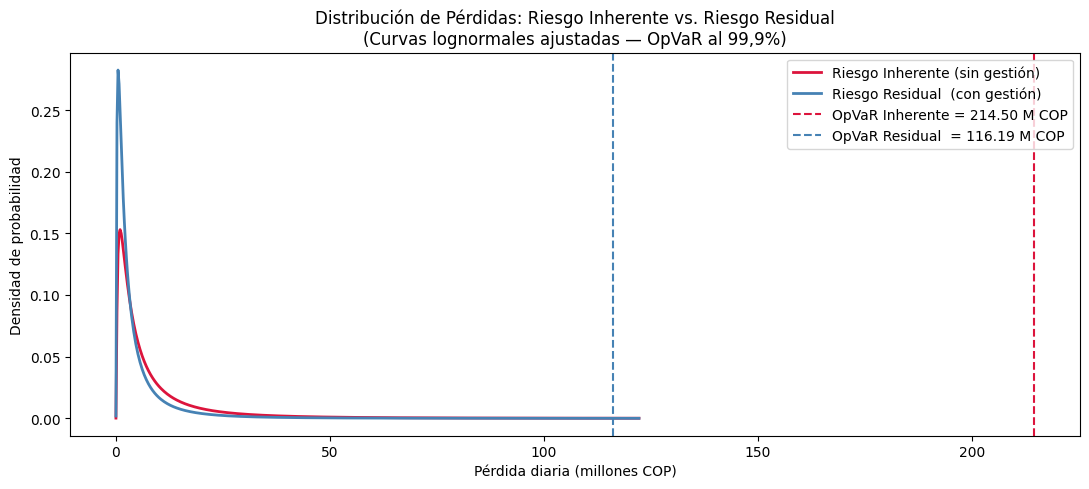

In [12]:
# ── GRÁFICO COMPARATIVO DE DISTRIBUCIONES ──────────────────────────────────
# Se visualiza el desplazamiento de la distribución de pérdidas al aplicar controles
x = np.linspace(0.01, max(LDA) * 1.1, 500)

# Se generan las PDF (funciones de densidad) de ambos escenarios
pdf_inh = stats.lognorm.pdf(x, s=sigma_log, scale=np.exp(mu_log))
pdf_res = stats.lognorm.pdf(x, s=sigma2,    scale=np.exp(mu2))

plt.figure(figsize=(11, 5))
plt.plot(x, pdf_inh, color='crimson',    linewidth=2, label='Riesgo Inherente (sin gestión)')
plt.plot(x, pdf_res, color='steelblue',  linewidth=2, label='Riesgo Residual  (con gestión)')
plt.axvline(OpVaR_inherente, color='crimson',   linestyle='--', linewidth=1.5,
            label=f'OpVaR Inherente = {OpVaR_inherente:.2f} M COP')
plt.axvline(OpVaR_residual,  color='steelblue', linestyle='--', linewidth=1.5,
            label=f'OpVaR Residual  = {OpVaR_residual:.2f} M COP')
plt.title("Distribución de Pérdidas: Riesgo Inherente vs. Riesgo Residual\n(Curvas lognormales ajustadas — OpVaR al 99,9%)", fontsize=12)
plt.xlabel("Pérdida diaria (millones COP)")
plt.ylabel("Densidad de probabilidad")
plt.legend()
plt.tight_layout()
plt.show()

## **Análisis de Resultados**

El promedio simple de cada falla tecnológica en los canales electrónicos tiene un costo de 4,048 millones de COP; sin embargo, cuando ponderamos este costo con la frecuencia real de los eventos, obtenemos que el costo promedio ponderado es de 2,175 millones de COP (valor cercano a la mitad del promedio simple). Esto ocurre porque la mayoría de las fallas son pequeñas y frecuentes, mientras que los eventos más costosos son raros, lo que "baja" el costo cuando se tiene en cuenta cuántas veces ocurre cada tipo de falla.

De acuerdo con la integración de la matriz de impacto, la pérdida esperada sube a 2,812 millones de COP, dado que ahora se le da más peso a las fallas que caen en celdas de alta criticidad operacional (aquellas que, además de frecuentes, generan un daño económico considerable para el banco).

---
**Al comparar dos escenarios:**

En el peor escenario posible (el que ocurre solo una vez cada mil días, es decir, el OpVaR al 99,9%), el banco podría enfrentar una pérdida de hasta 214,50 millones de COP en un solo día si no tiene controles activos (Riesgo Inherente). Este es el capital que debería estar "guardado" para sobrevivir ese día sin problemas.

Por otro lado, al implementar controles de gestión en nivel 2 (revisión de logs, alertas automáticas, protocolos de contingencia para fallas intermedias), la distribución de pérdidas se desplaza hacia la izquierda: el OpVaR se reduce a 116,19 millones de COP(Riesgo Residual). Eso representa una reducción del 45,8% en el capital que el banco necesita reservar (es decir, los controles "liberan" casi 98 millones de COP de capital que, en cambio, podrían destinarse a inversión productiva).

---

**Respecto a la matriz de gestión:**

- Las celdas con nivel de impacto 1 (fallas triviales y muy raras) y nivel 5 (colapso total del sistema) no se gestionan proactivamente: las primeras porque no justifican el costo de intervención, y las segundas porque su escala supera cualquier plan de control ordinario (para estas se activan planes de recuperación ante desastres y comunicación a entes reguladores o seguros, etc..)
- Las celdas de niveles 2, 3 y 4 son el foco real de la gestión: son lo suficientemente frecuentes y costosas como para que invertir en controles genere un retorno claro en reducción de pérdidas esperadas.

En conclusión, gestionar bien los riesgos tecnológicos de nivel medio no solo protege al banco de pérdidas graves, sino que también mejora la eficiencia del capital regulatorio.

#
**6. Herramienta de Auditoría**



Se construye un tablero interactivo que permite al equipo auditor seleccionar cualquier celda de la **Matriz de Pérdidas Agregadas** y obtener el detalle completo de los eventos que la componen: fechas, volumen de transacciones, número de fallas, costo individual y descripción del evento.

In [13]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── Se construye la etiqueta de cada nivel para los menús desplegables ──────
etiquetas_freq = {
    0: "Nivel 0 — Improbable",
    1: "Nivel 1 — Posible",
    2: "Nivel 2 — Ocasional",
    3: "Nivel 3 — Probable",
    4: "Nivel 4 — Frecuente"
}
etiquetas_sev = {
    0: "Nivel 0 — Insignificante",
    1: "Nivel 1 — Leve",
    2: "Nivel 2 — Moderado",
    3: "Nivel 3 — Grave",
    4: "Nivel 4 — Catastrófico"
}

# ── Se crean los menús desplegables para seleccionar la celda de interés ────
selector_freq = widgets.Dropdown(
    options=[(v, k) for k, v in etiquetas_freq.items()],
    description='Frecuencia:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='350px')
)
selector_sev = widgets.Dropdown(
    options=[(v, k) for k, v in etiquetas_sev.items()],
    description='Severidad:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='350px')
)
boton = widgets.Button(
    description='🔍 Ver eventos de esta celda',
    button_style='primary',
    layout=widgets.Layout(width='250px')
)
salida = widgets.Output()

# ── Función que se ejecuta al presionar el botón ────────────────────────────
def filtrar_eventos(b):
  with salida:
    clear_output(wait=True)

    # Se obtienen los niveles seleccionados por el usuario
    nf_sel = selector_freq.value
    ns_sel = selector_sev.value

    # Se filtran los eventos de la base de datos que pertenecen a esa celda
    mascara = (df['Nivel_f'] == nf_sel) & (df['Nivel_S'] == ns_sel)
    eventos_celda = XDB[mascara.values].copy()
    eventos_celda.reset_index(drop=True, inplace=True)

    # Se muestra el encabezado del reporte de auditoría
    print(f"{'='*70}")
    print(f"  REPORTE DE AUDITORÍA — CELDA SELECCIONADA")
    print(f"  Frecuencia : {etiquetas_freq[nf_sel]}")
    print(f"  Severidad  : {etiquetas_sev[ns_sel]}")
    print(f"{'='*70}")

    if len(eventos_celda) == 0:
      print("  No se registraron eventos en esta celda.")
    else:
      # Se calculan los totales de la celda para el resumen ejecutivo
      total_fallas  = eventos_celda.iloc[:, 3].sum()
      costo_prom    = eventos_celda.iloc[:, 4].mean()
      perdida_total = (eventos_celda.iloc[:, 3] * eventos_celda.iloc[:, 4]).sum()

      print(f"  Total de días con eventos:        {len(eventos_celda)}")
      print(f"  Total de transacciones fallidas:  {total_fallas:.0f}")
      print(f"  Costo promedio por falla:         {costo_prom:.4f} M COP")
      print(f"  Pérdida agregada estimada:        {perdida_total:.4f} M COP")
      print(f"{'='*70}\n")

      # Se muestra el detalle evento por evento (renombrando columnas para mayor claridad)
      detalle = eventos_celda.copy()
      detalle.columns = ['Fecha', 'Trans. Diarias', 'Valor Transado (M)', 'Trans. Fallidas',
                         'Valor por Falla (M)', 'Descripción del Evento']
      detalle['Pérdida del Día (M)'] = detalle['Trans. Fallidas'] * detalle['Valor por Falla (M)']
      detalle['Fecha'] = pd.to_datetime(detalle['Fecha']).dt.strftime('%Y-%m-%d')

      # Se formatea la tabla de detalle para impresión limpia
      pd.set_option('display.max_colwidth', 80)
      pd.set_option('display.max_rows', None)
      display(detalle[['Fecha', 'Trans. Fallidas', 'Valor por Falla (M)',
                        'Pérdida del Día (M)', 'Descripción del Evento']])

boton.on_click(filtrar_eventos)

# ── Se ensambla y despliega el tablero ─────────────────────────────────────
print("HERRAMIENTA DE AUDITORÍA — Filtro Dinámico de Eventos de Riesgo Tecnológico")
print("Seleccione el nivel de frecuencia y severidad de la celda a auditar:\n")
display(widgets.VBox([
    widgets.HBox([selector_freq, selector_sev]),
    boton,
    salida
]))

HERRAMIENTA DE AUDITORÍA — Filtro Dinámico de Eventos de Riesgo Tecnológico
Seleccione el nivel de frecuencia y severidad de la celda a auditar:

